# GAAS Analysis Steps:

1. Calculate Transferability Matrix
2. Calculate Cos Similarity for each example
    
    a. Calc average for each model
    
3. Compare the adversarial subspace to Transferability Matrix

In [2]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import torch
from robustbench import load_model
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# CIFAR-10 class names
CLASSES = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

MODELS = [
            "Bartoldson2024Adversarial_WRN-94-16", 
            "Amini2024MeanSparse_S-WRN-94-16",
            "Peng2023Robust",
            "Bai2024MixedNUTS",
            "Sehwag2021Proxy_ResNest152",
            "Gowal2021Improving_R18_ddpm_100m",
            "Debenedetti2022Light_XCiT-L12",
            "Sehwag2021Proxy_R18",
            "Standard"
        ]

PERTURBED_DATA = [
    "data/targetedFGSM_perterbances/cifar10_Bartoldson2024Adversarial_WRN-94-16_WRN_94_16_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_amini2024meansparse_s-wrn-94-16_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_peng2023robust_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_bai2024mixednuts_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Sehwag2021Proxy_ResNest152_ResNest152_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Gowal2021Improving_R18_ddpm_100m_R18_ddpm_100m_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Debenedetti2022Light_XCiT-L12_XCiT_L12_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_Sehwag2021Proxy_R18_R18_linf_eps8_adv.pt",
    "data/targetedFGSM_perterbances/cifar10_standard_linf_adv.pt"
]

CAT_IDX = 3
DOG_IDX = 5
BINARY_CLASSES = {CAT_IDX: "cat", DOG_IDX: "dog"}

# L-inf threat-model budget (8/255 is the standard CIFAR-10 benchmark)
EPSILON = 8 / 255

print(f"Binary subset: {CAT_IDX}=cat  {DOG_IDX}=dog  epsilon={EPSILON:.5f}")

def pkl_save(a, path):
    with open(path, 'wb') as handle:
        pickle.dump(a, handle, protocol=pickle.HIGHEST_PROTOCOL)

def pkl_load(path):
    with open(path, 'rb') as handle:
        return pickle.load(handle)


/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Binary subset: 3=cat  5=dog  epsilon=0.03137


/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/robustbench/loaders.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Load all cat/dog data

In [3]:
# load n data pts, 2000 = all cat/dog pts
def build_catdog_dataset(n=2000):
    """Sample n Cat and Dog images from the CIFAR-10 test set."""
    ds         = datasets.CIFAR10(root="./data", train=False,
                                   download=True, transform=transforms.ToTensor())
    indices    = [i for i, (_, lbl) in enumerate(ds)
                  if lbl in (CAT_IDX, DOG_IDX)]
    np.random.seed(42)
    chosen     = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    loader     = DataLoader(Subset(ds, chosen),
                            batch_size=len(chosen), shuffle=False)
    imgs, lbls = next(iter(loader))
    return imgs, lbls
ci, cl       = build_catdog_dataset()
images = ci.to(device)
clean_labels = cl.to(device)
print(f"Sampled {len(clean_labels)} Cat/Dog images from test set.")

Sampled 2000 Cat/Dog images from test set.


# Loading huggingface model

In [4]:
# Clone the repository directly if it doesn't exist in the working directory
from pathlib import Path
import subprocess
import sys


repo_dir = Path('ViT-Classification-CIFAR10')
if not repo_dir.exists():
    print("Cloning GitHub repository...")
    subprocess.check_call(['git', 'clone', 'https://github.com/nick8592/ViT-Classification-CIFAR10.git'])

# Append repository path to sys.path so we can import the model architecture directly
if str(repo_dir.resolve()) not in sys.path:
    sys.path.append(str(repo_dir.resolve()))

In [31]:
from model import VisionTransformer
print('  Initializing model with explicit architecture arguments...')
hf_model = VisionTransformer(
    n_channels=3,
    embed_dim=128,
    n_layers=6,
    n_attention_heads=4,
    forward_mul=2,
    image_size=32,
    patch_size=4,
    n_classes=10
)

# Point directly to your manually downloaded local file
checkpoint_path = Path("vit-layer6-32-cifar10-199.pt")

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Could not find '{checkpoint_path.name}' in your current working directory. "
        "Make sure it's placed in the root directory next to your notebook."
    )

print(f'  [READY] Loading localized checkpoint asset matrix from: {checkpoint_path}')
state_dict = torch.load(checkpoint_path, map_location='cpu')

if 'state_dict' in state_dict: state_dict = state_dict['state_dict']
elif 'model' in state_dict: state_dict = state_dict['model']

hf_model.load_state_dict(state_dict, strict=True)
hf_model = hf_model.to(device)
hf_model.eval()

for param in hf_model.parameters():
    param.requires_grad_(False)

  Initializing model with explicit architecture arguments...
  [READY] Loading localized checkpoint asset matrix from: vit-layer6-32-cifar10-199.pt


# Setup functions for evaluating model on only cat/dog

In [5]:
def pred_model(m, images):
    # returns the predicted label of either cat or dog
    with torch.no_grad():
        out = m(images)

    pred = out[:, [CAT_IDX, DOG_IDX]].argmax(dim=1) # 0 = cat, 1 = dog
    pred[pred == 0] = CAT_IDX
    pred[pred == 1] = DOG_IDX

    return pred

def pred_model_hf_vit(m, images):
    # returns the predicted label of either cat or dog
    with torch.no_grad():
        out = m(images)[0]

    pred = out[:, [CAT_IDX, DOG_IDX]].argmax(dim=1) # 0 = cat, 1 = dog
    pred[pred == 0] = CAT_IDX
    pred[pred == 1] = DOG_IDX

    return pred

# Load adversarial examples and get transferability matrix for each model.

In [6]:
#Load saved adversarial examples and perturbations from the files in experiment_configs
def torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

In [ ]:
perturbed_data = []
fooled_examples = []
for perturbed_path, model_id in zip(PERTURBED_DATA, MODELS):
    print(model_id)
    adv_data = torch_load(perturbed_path)
    adv_images = adv_data['adv_images']
    loaded_model = load_model(model_name=model_id,
                            dataset="cifar10",
                            threat_model="Linf").to(device)
    loaded_model.eval()
    pred = pred_model(loaded_model, images)
    adv_pred = pred_model(loaded_model, adv_images)
    fooled_examples.append((pred == clean_labels) & (adv_pred != clean_labels)) # for transferability we only want to check for examples that fooled model a
    del loaded_model
    perturbed_data.append(adv_data)

In [32]:
# hugging face specific now
adv_data = torch_load('data/targetedFGSM_perterbances/cifar10_nick8592_vit-classification-cifar10_linf_adv.pt')
adv_images = adv_data['adv_images']
hf_model.eval()
pred = pred_model_hf_vit(hf_model, images)
adv_pred = pred_model_hf_vit(hf_model, adv_images)
fooled_examples.append((pred == clean_labels) & (adv_pred != clean_labels))
perturbed_data.append(adv_data)

In [33]:
t_matrix = np.zeros(shape=(len(MODELS)+1, len(MODELS)+1)) # transferability matrix, % of times fooled 
m = 0
for model_id in MODELS:
    print(model_id)
    loaded_model = load_model(model_name=model_id,
                            dataset="cifar10",
                            threat_model="Linf").to(device)
    loaded_model.eval()
    am = 0
    for x, fooled in zip(perturbed_data, fooled_examples):
        adv_image    = x['adv_images'][fooled]

        adv_pred = pred_model(loaded_model, adv_image)
        adv_acc = (adv_pred != clean_labels[fooled]).float().mean().item() # adv acc = fooling rate
        t_matrix[m][am] = adv_acc
        am += 1
    del loaded_model # free memory, these models are like giga bytes large
    m+=1

Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
The STD classifier has 232279184 parameters. 232279184 parameters are trainable.
The ROB classifier has 267240802 parameters. 267240802 parameters are trainable.
Using alpha=0.9987500602493457.
Using alpha_diffable=0.9570535356459247.
Bypassing robust base model nonlinear transformation for gradient calculations.
Disabling autocast.


/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/robustbench/model_zoo/architectures/mixing_net.py:237: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=enable_autocast):


Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18
Standard


In [34]:
# hf model specific
m = len(MODELS)
am = 0
for x, fooled in zip(perturbed_data, fooled_examples):
    adv_image    = x['adv_images'][fooled]

    adv_pred = pred_model_hf_vit(hf_model, adv_image)
    adv_acc = (adv_pred != clean_labels[fooled]).float().mean().item() # adv acc = fooling rate
    t_matrix[m][am] = adv_acc
    am += 1

In [35]:
np.save('transfer_matrix', t_matrix)

# if t matrix is saved start here

In [7]:
t_matrix = np.load('transfer_matrix.npy')

In [59]:
def convert_to_numpy(arr):
    temp = []
    for a in arr:
        temp.append(a.cpu().view(-1).numpy())
    return np.array(temp)

def cos_sim(a, b):
    a = convert_to_numpy(a)
    b = convert_to_numpy(b)
    a_n = a / (np.linalg.norm(a, keepdims=True) + 1e-8)
    b_n = b / (np.linalg.norm(b, keepdims=True) + 1e-8)
    return a_n @ b_n.T

def mean_cos_sim(a, b):
    a = convert_to_numpy(a).mean(axis=0)
    b = convert_to_numpy(b).mean(axis=0)
    a_n = a / (np.linalg.norm(a, keepdims=True) + 1e-8)
    b_n = b / (np.linalg.norm(b, keepdims=True) + 1e-8)
    return a_n @ b_n.T

def analyse_gaas_ex(A, B, sim_func=cos_sim):
    # get both cos similarity and combined lengths of each example direction size
    # untargeted stats
    i_u = 0
    ds_u = 0
    coss_u = 0

    # targeted stats
    i_t = 0
    ds_t = 0
    coss_t = 0

    for a, b in zip(A, B):
        a_u = a[0]
        b_u = b[0]
        if len(a_u) != 0 and len(b_u) != 0:
            ds_u += len(a_u) + len(b_u)
            coss_u += np.mean(sim_func(a_u, b_u))
            i_u += 1

        a_t = a[1]
        b_t = b[1]
        if len(a_t) != 0 and len(b_t) != 0:
            ds_t += len(a_t) + len(b_t)
            coss_t += np.mean(sim_func(a_t, b_t))
            i_t += 1

    return coss_u / i_u, ds_u / i_u, coss_t / i_t, ds_t / i_t



generate gaas stats on all directions for each example and record the average cos sim

In [ ]:
gaas_stats = np.zeros(shape=(len(MODELS)+1, len(MODELS)+1, 4))
ai = 0
for ma in MODELS:
    print(ma)
    # load perturbance directions from A and B
    A = pkl_load(ma + '.pickle')

    bi = 0
    for mb in MODELS:
        B = pkl_load(mb + '.pickle')

        gaas_stats[ai][bi] = analyse_gaas_ex(A, B)
        bi += 1
    # specific case for hugging face vit
    B = pkl_load('vit-layer6-32-cifar10-199.pickle')

    gaas_stats[ai][bi] = analyse_gaas_ex(A, B)
    ai += 1

# last little manual hugging face stat calc
print('hf vit')
A = pkl_load('vit-layer6-32-cifar10-199.pickle')
ai = len(MODELS)
bi = 0
for mb in MODELS:
    B = pkl_load(mb + '.pickle')

    gaas_stats[ai][bi] = analyse_gaas_ex(A, B)
    bi += 1
# specific case for hugging face vit
B = pkl_load('vit-layer6-32-cifar10-199.pickle')
gaas_stats[ai][bi] = analyse_gaas_ex(A, B)
np.save('gaas_overall_stats', gaas_stats)

stats of cosine similarity using the average adversarial direction of an example

In [65]:
mean_gaas_stats = np.zeros(shape=(len(MODELS)+1, len(MODELS)+1, 4))
ai = 0
for ma in MODELS:
    print(ma)
    # load perturbance directions from A and B
    A = pkl_load(ma + '.pickle')

    bi = 0
    for mb in MODELS:
        B = pkl_load(mb + '.pickle')

        mean_gaas_stats[ai][bi] = analyse_gaas_ex(A, B, sim_func=mean_cos_sim)
        bi += 1
    # specific case for hugging face vit
    B = pkl_load('vit-layer6-32-cifar10-199.pickle')

    mean_gaas_stats[ai][bi] = analyse_gaas_ex(A, B, sim_func=mean_cos_sim)
    ai += 1

# last little manual hugging face stat calc
print('hf vit')
A = pkl_load('vit-layer6-32-cifar10-199.pickle')
ai = len(MODELS)
bi = 0
for mb in MODELS:
    B = pkl_load(mb + '.pickle')

    gaas_stats[ai][bi] = analyse_gaas_ex(A, B, sim_func=mean_cos_sim)
    bi += 1
# specific case for hugging face vit
B = pkl_load('vit-layer6-32-cifar10-199.pickle')
mean_gaas_stats[ai][bi] = analyse_gaas_ex(A, B, sim_func=mean_cos_sim)

# save
np.save('gaas_mean_stats', mean_gaas_stats)

Bartoldson2024Adversarial_WRN-94-16
Amini2024MeanSparse_S-WRN-94-16
Peng2023Robust
Bai2024MixedNUTS
Sehwag2021Proxy_ResNest152
Gowal2021Improving_R18_ddpm_100m
Debenedetti2022Light_XCiT-L12
Sehwag2021Proxy_R18
Standard
hf vit


# Start here if have all data

In [32]:
"""
t_matrix: Row m, column n = model m evaluating on model n's adv images that fooled itself

gaas_stats:
    m x m x 4 matrix
    [0] = cos sim of untargeted directions
    [1] = average num of untargeted directions between the two models
    [2] = cos sim of targeted directions
    [3] = average num of targeted directions between the two models
"""
t_matrix = np.load('transfer_matrix.npy')
gaas_stats = np.load('gaas_overall_stats.npy')

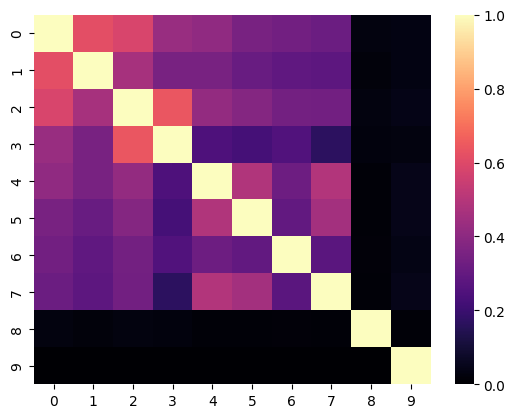

In [67]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# im = sns.heatmap(gaas_stats[:, :, 0], vmax=1, cmap='magma')
im = sns.heatmap(mean_gaas_stats[:, :, 2], vmax=1, cmap='magma')
# plt.colorbar(im, ax=axes[0], label="Cosine similarity")


<Axes: >

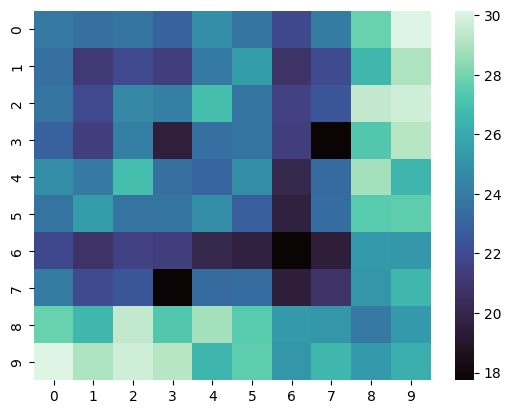

In [52]:
sns.heatmap(gaas_stats[:, :, 1], cmap='mako')

<Axes: >

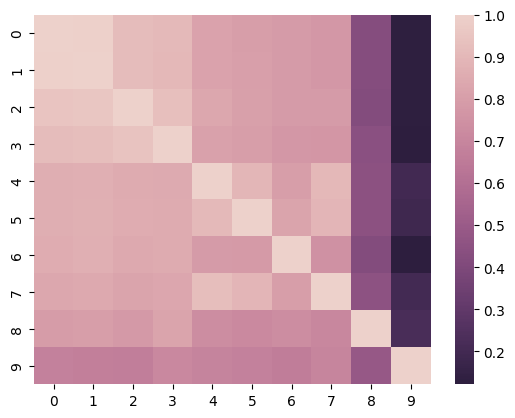

In [10]:
sns.heatmap(t_matrix, cmap=sns.cubehelix_palette(as_cmap=True, reverse=True))

# Global direction analysis

In [ ]:
def get_global_direction(A, clean_labels, dims=3072):
    # we return:
    #   1. global untargeted
    #   2. global cat targeted 
    #   3. global dog targeted

    untargeted = np.empty(shape=(dims))
    cat_targeted = np.empty(shape=(dims))
    dog_targeted = np.empty(shape=(dims))

    for a, clean_label in zip(A, clean_labels):
        a_u = a[0]
        a_t = a[1]

        if len(a_u) != 0:
            np.append(untargeted, convert_to_numpy(a_u))
        if clean_label == CAT_IDX:
            dog_targeted.append()


    return